本文为笔记, 原文在[这里](https://nlp.seas.harvard.edu/2018/04/03/attention.html)

# Transformer模型

In [35]:
import copy
import torch 
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math, copy, time

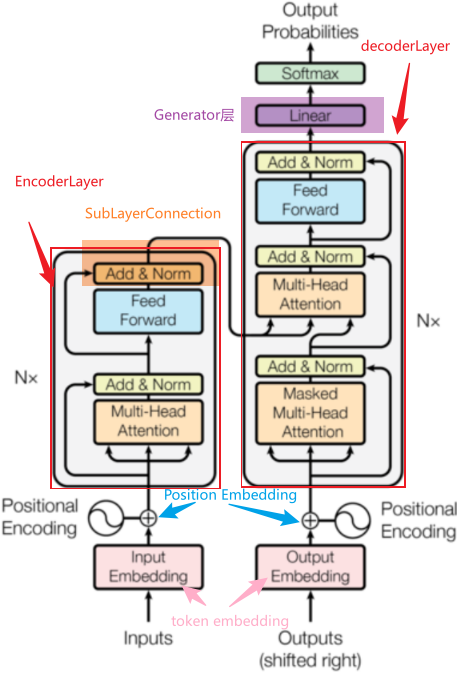

## Generator 层

和Transformer网络无关, 只用来网络提取的特征进行分类

先定义一个Generator类，用于将Transformer的输出映射到词汇表的概率分布上。

In [36]:
class Generator(nn.Module):
    "定义一个线性层 + softmax 进行预测分化"
    def __init__(self, dim_model, vocab):
        super(Generator, self).__init__()
        self.proj = nn.Linear(dim_model, vocab)
    
    def forward(self, x):
        return F.log_softmax(self.proj(x), dim=-1)
    

## LayerNorm 

In [ ]:
class LayerNorm(nn.Module):
    "LN层是对一个样本的所有特征进行归一化, self.a_2和self.b_2是可学习的缩放和平移参数"
    def __init__(self, model_dim, eps=1e-6):
        super(LayerNorm, self).__init__()
        self.a_2 = nn.Parameter(torch.ones(model_dim))
        self.b_2 = nn.Parameter(torch.zeros(model_dim))
        self.eps = eps
    
    def forward(self, x):
        # 这里keepdim=True是为了后续的广播机制, mean和std的shape是(batch_size, seq_len, 1)
        # 广播机制会自动将最后一维扩展到和x相同的维度, 即(batch_size, seq_len, model_dim)
        # x.shape = (batchsize, seq_len, dim_models)
        mean = x.mean(dim = -1, keepdim=True)
        std = x.std(dim = -1, keepdim=True)
        
        # 标准化公式, self.a_2是缩放参数, self.b_2是平移参数, self.eps是为了防止除0错误
        return self.a_2 * (x-mean) / (std + self.eps) + self.b_2

## subLayerConnection = LN + sublayer + dropout + residual

不论是Decoder layer 还是 endcoder layer , 都会用到LayerNorm 和 dropout 层 和 残差层

现在大多数使用的都是Pre-LN的写法, 即 LayerNorm -> sublayer -> residual layer


In [38]:
class SublayerConnection(nn.Module):
    "定义一个子层连接, 包括LayerNorm和dropout"
    
    def __init__(self, model_dim, dropout):
        super(SublayerConnection, self).__init__()
        self.norm = LayerNorm(model_dim)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, sublayer, x): 
        return x + self.dropout(sublayer(self.norm(x)))

## Encoder

Transformer的Encoder是由多个encoder_layer组成

encoder layer的组成是 
LayerNorm + mutihead Attention + dropout + residual + 
LayerNorm + FFN + dropout + residual 

Encoder = encoder_layer * num_layers


In [39]:
class Encoder(nn.Module):
    "定义Encoder结构, 是由多个Encoder_layer组成, 最后接一个LayerNorm"
    def __init__(self, layer, num_layers):
        super(Encoder, self).__init__()
        self.layers = nn.ModuleList([copy.deepcopy(layer) for _ in range(num_layers)])
        # LayerNorm 是根据输入的最后一个维度进行归一化的, 因此也是根据这个创建
        # 基本这个维度就是模型中间层的输出维度
        self.norm = LayerNorm(layer.model_dim)

    def forward(self, x, mask):
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)

### EncoderLayer

其中有两个层, 一个是Attention, 一个是FFN

In [40]:
class EncoderLayer(nn.Module):
    "定义Encoder Layer结构, 包括两个子层: multihead attention 和 feed forward"
    
    def __init__(self, model_dim, self_atten, feed_forward, dropout):
        super(EncoderLayer, self).__init__()
        self.self_atten = self_atten
        self.feed_forward = feed_forward
        # 这里有两个sublayer, 因此需要创建两个SublayerConnection
        self.sublayers = nn.ModuleList([copy.deepcopy(SublayerConnection(model_dim, dropout)) for _ in range(2)])
        self.model_dim = model_dim
        
    def forward(self, x, mask):
        # 依次通过self attention 和 feed forward
        x = self.sublayers[0](lambda x : self.self_atten(x, x, x, mask), x)
        x = self.sublayers[1](self.feed_forward, x)
        return x

## Decoder

Decoder 由于num_layers个DecoderLayer组成

每个DecoderLayer包含三个子层: self attention, enc-dec attention, feed forward.

In [41]:
class Decoder(nn.Module):
    "定义Decoder结构, 由多个DecoderLayer组成"
    
    def __init__(self, layer, num_layers):
        super(Decoder, self).__init__()
        self.layers = nn.ModuleList([copy.deepcopy(layer) for _ in range(num_layers)])
        self.norm = LayerNorm(layer.model_dim)
        
    def forward(self, x, memory, src_mask, tgt_mask):
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.norm(x)
    

### DecoderLayer

In [ ]:
class DecoderLayer(nn.Module):
    "定义 DecoderLayer, DecoderLayer = self-attention + src-attention + feed forward"
    
    def __init__(self, model_dim, self_atten, src_atten, feed_forward, dropout):
        super(DecoderLayer, self).__init__()
        self.model_dim = model_dim
        self.self_atten = self_atten
        self.src_atten = src_atten
        self.feed_forward = feed_forward
        self.sublayers = nn.ModuleList([copy.deepcopy(SublayerConnection(model_dim, dropout)) for _ in range(3)])   
    
    def forward(self, x, memory, src_mask, tgt_mask):
        x = self.sublayers[0](lambda x : self.self_atten(x, x, x, tgt_mask), x)
        # 注意这里的memory是Encoder的输出, 因为encoder已经归一化很多层, 数据基本稳定, 因此不需要再归一化
        x = self.sublayers[1](lambda x : self.src_atten(query = x, key = memory, value = memory, mask = src_mask), x)
        x = self.sublayers[2](self.feed_forward, x)
        return x
    

制作后续掩码主要用于制作tgt_mask, 因为tgt_mask是自注意力机制, 因此在翻译的过程当中

预测下一个token的时候, 不应该看到未来的token 信息, 因此需要把在第i个位置预测的时候

需要把i+1以及以后位置的token信息进行mask

In [43]:
def subsequent_mask(size):
    """
    制作后续掩码, 用于mask未来的信息, 这里的size是序列的长度(一句话token的数量)
    subsequent_mask 中True表示可以看到, False表示mask掉
    """
    
    atten_shape = (1, size, size)
    # np.triu用于生成上三角矩阵, k=1表示取 主对角线向上偏移一位 的元素全部设置为1
    subsequent_mask = np.triu(np.ones(atten_shape), k=1).astype('uint8')
    
    # 把矩阵的0和1进行转换, 变成True和False
    subsequent_mask = torch.tensor(subsequent_mask, dtype=torch.bool) == 0
    return subsequent_mask

运行下看看subsequent_mask的效果

tensor([[ True, False, False, False],
        [ True,  True, False, False],
        [ True,  True,  True, False],
        [ True,  True,  True,  True]])


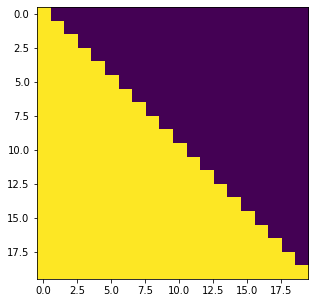

In [44]:
plt.figure(figsize=(5,5))
plt.imshow(subsequent_mask(20)[0])

#plt.imshow(...) 会返回一个 AxesImage 对象，如果不想在 notebook 输出显示这个对象的 
# <matplotlib.image.AxesImage at 0x...>，就加一个 None。
None

# 看看什么样子, True为mask, false为保留
print(subsequent_mask(4)[0])

## Attention注意力机制

### DotProductAttention


先实现一个单头点积Attention机制

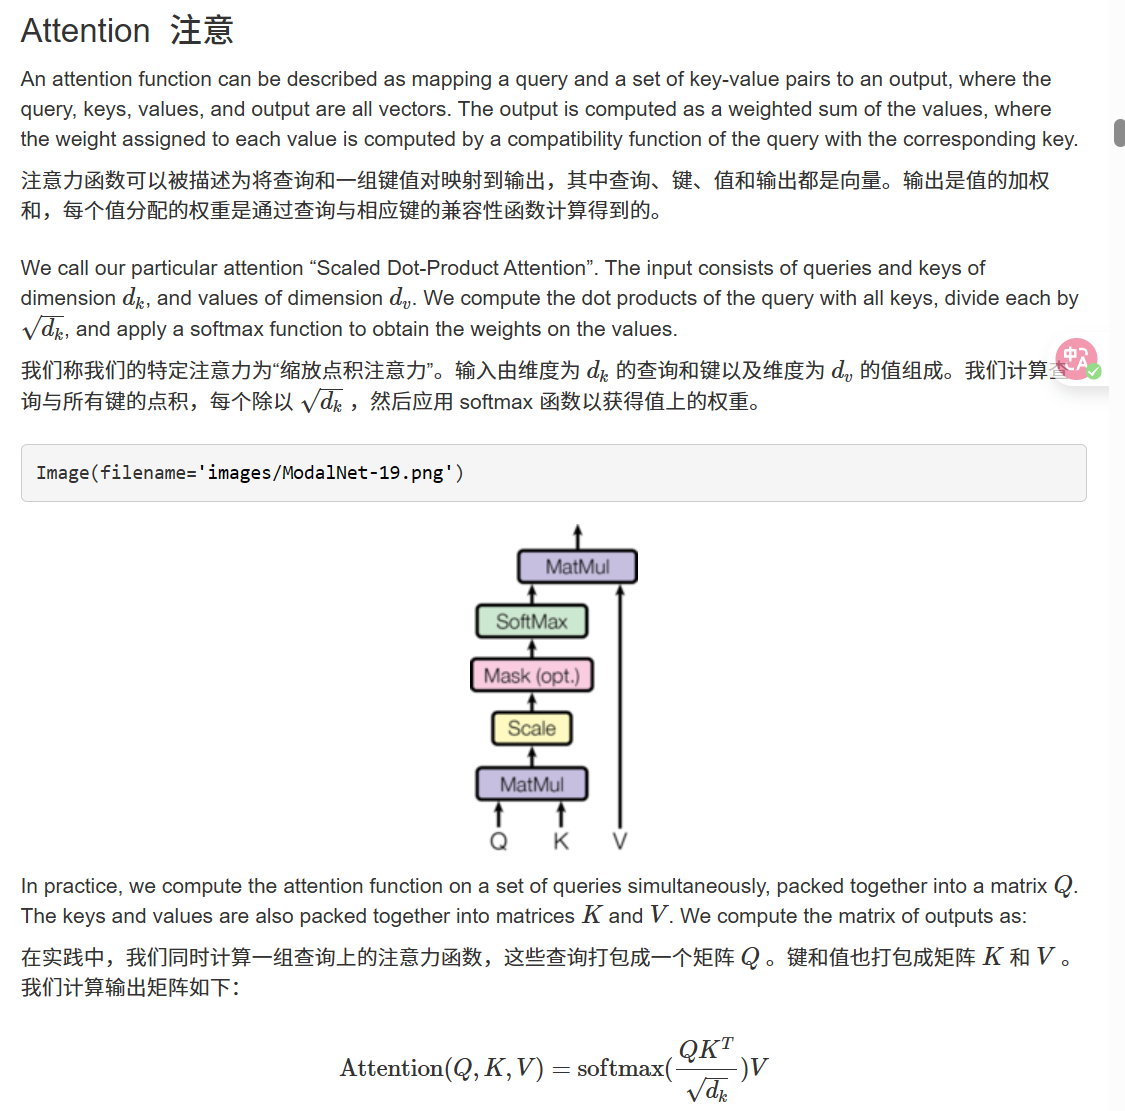

**注意力机制当中拉伸的原因**

图中的Scale是$\sqrt(d_k)$, 用于缩短数值之间的差距, 让softmax后的数据不会出现较大的方差, 更好的训练, 原因可看 : [softmax 演示](../PyTorch源码教程与前沿人工智能算法复现讲解/code/19.%20Transformer模型Encoder原理精讲及其PyTorch逐行实现.ipynb)

**注意力机制当中Mask的原因**

对于score计算完后, 无效的位置是0, 有效的地方是一些正数, 然后丢入到softmax当中, 由于softx用的是e的指数函数, 因此无效区域e^0 = 1, 这样会占据比较大的权重, 因此用mask机制对于无效的区域填写成-1e9, 这样用上套入指数函数当中, 其在softmax当中的权重就是近似于0



Q.shape = (batchsize, nums_head, query_len, dim_k)

K.shape = (batchsize, nums_head, key_len, dim_k)

$QK^T$.shape = (batchsize, nums_head, query_len, key_len)

V.shape = (batchsize, nums_head, key_len, dim_k) 一般key 和 value 是同一个东西

Attention.shape = (batchsize, nums_head, query_len, dim_k)

mask.shape = (batchsize, 1, 1, key_len) 这里第一个1代表多头的维度, 第二个1代表query的维度, key_len 一般就是src 或者 tgt 的一句话token的数量

In [45]:

# 这里的Attention 使用dot-Attention机制
# 还有其他的Attention机制, 比如说add-Attention机制等

class DotProductAttention(nn.Module):
    """
    点积注意力机制, 输入是query, key, value, mask可选
    这里的点注意力机制是在多头注意力中使用的 所以输入都是4D的tensor
    query: (batch_size, nums_head, query_len, d_k)
    key: (batch_size, nums_head, key_len, d_k)
    value: (batch_size, nums_head, key_len, d_k) (因为key和value都是同一个)
    
    输出: atten: (batch_size, nums_head, query_len, d_k)
          p_attn: Q和K的相似值经过softmax后的结果 (batch_size, nums_head, query_len, key_len)
          torch.matmul的返回值是(batch_size, nums_head, query_len, d_k)
    """
    
    def __init__(self, dropout=0.1):
        super(DotProductAttention, self).__init__()
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, query, key, value, mask=None):
        d_k = query.shape[-1]
        scores = torch.matmul(query, key.transpose(-2, -1)) / np.sqrt(d_k)
        # 这里对mask
        if mask is not None : 
            scores = scores.masked_fill(mask == 0, -1e9)
        p_attn = F.softmax(scores, dim=-1)
        p_attn = self.dropout(p_attn)
        return torch.matmul(p_attn, value), p_attn

### MultiHeadedAttention


多头注意力机制

值得注意, 在注意力机制当中, 将key,query, value 的特征维度分割成nums_head份的时候

一定要将他们丢入到Linear层进行学习, 只有这样出来的特征才是经过学习的投影, 而不是选择直接在原始的
embedding上进行切割(这会让每个头看到的信息高度相关, 而不是mutihead-Attention强调的不同的角度的
关注方式)

In [46]:
class MultiHeadedAttention(nn.Module):
    """
    多头注意力机制
    init : dim_model: 模型的维度, num_heads: 注意力头的数量, dropout: dropout概率
    forward : x.shape = [batchsize, num_steps, dim_model], 输出x.shape保持不变
    """
    def __init__(self, num_heads, dim_model, dropout=0.1):
        super(MultiHeadedAttention, self).__init__()
        # dim_model 必须能够被 num_heads 整除
        # d_k是单头转化成多头后的特征维度   
        assert dim_model % num_heads == 0
        self.d_k = dim_model // num_heads
        self.num_heads = num_heads
        self.p_attn = None
        
        # 创建4个线性层, 分别用于对query, key, value进行线性变换, , 最后一个用于对多头的输出进行线性变换
        self.Linears = nn.ModuleList([copy.deepcopy(nn.Linear(dim_model, dim_model)) for _ in range(4)])
        # 创建点积注意力机制
        self.dot_product_attention = DotProductAttention(dropout)
        
    def forward(self, query, key, value, mask=None):
        size_batch = query.shape[0]

        if mask is not None:
            # 在多头注意力机制中, mask的维度需要从(size_batch, query_len, key_len) 扩展到 (size_batch, num_heads, query_len, key_len)
            mask = mask.unsqueeze(1)
                
        # 将 query, key, value 各自放入到Linear层后的特征维度进行分割, 然后reshape成多头的形式
        # 将query, key, value 从(size_batch, seq_len ,num_heads, dim_model)转化成(size_batch, num_heads, seq_len, dim_model)
        query, key, value = [linear(x).view(size_batch, -1, self.num_heads, self.d_k).transpose(1,2) 
                             for linear, x in zip(self.Linears[:3], (query, key, value))]
        
        # 丢入到单头Attention里面, x输出为(batch_size, nums_head, seq_len, d_k)
        x, self.p_attn = self.dot_product_attention(query = query, key = key, value = value, mask = mask)

        # 将多头提取的信息进行融合合并
        x = x.transpose(1, 2).contiguous().view(size_batch, -1, self.num_heads * self.d_k)
        x = self.Linears[-1](x)

        return x
        

## FFN网络

FFN网络其实就是两个全连接层, 然后FFN是不会跨越Token的

他每次处理的对象是同一个Token里面的位置特征

为什么可以学习到位置信息 ? 因为数据进来之前就已经embeding过了, 因此每个token中的信息就是已经有位置信息, 这个FFN层其实就是更好的学习这个位置信息

感觉可要可不要

In [47]:
class PositionwiseFeedForward(nn.Module):
    """
    FFN网络用语学习位置信息
    dim_model 是 模型的特征维度大小
    dim_ff 是 FFN网络中间层的特征维度大小
    """
    
    def __init__(self, dim_model, dim_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.w_1 = nn.Linear(dim_model, dim_ff)
        self.w_2 = nn.Linear(dim_ff, dim_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(F.relu(self.w_1(x))))
    


## Token Embedding 层

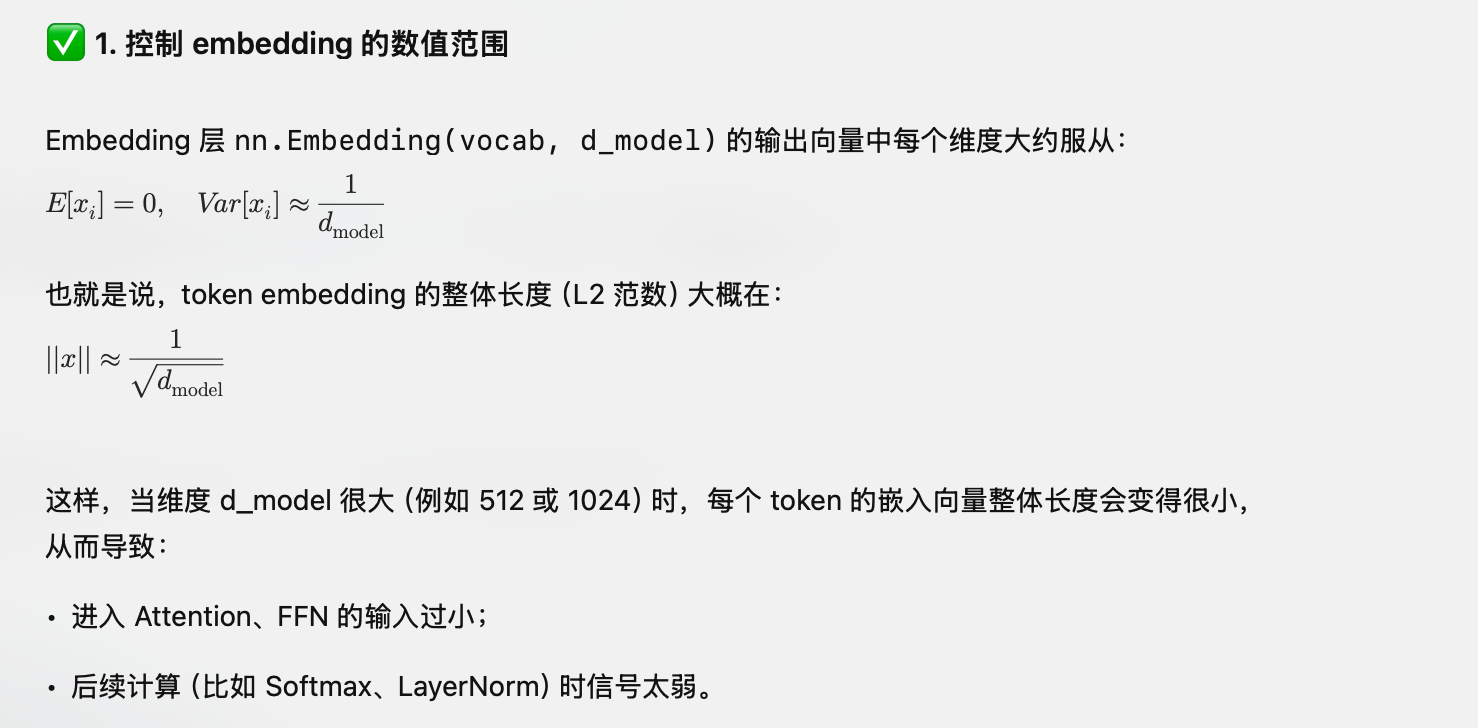

这里Token Embedding 后乘以系数的原因

In [48]:
class TokenEmbedding(nn.Module):
    """
    词嵌入层 
    init : dim_model 是把词语映射到dim_model长度的向量, vobal是词表大小
    forward: 输入x.shape = [batchsize, numsteps], 输出是[batchsize, numsteps, dim_model]
    """
    def __init__(self, dim_model, vobal):
        super(TokenEmbedding, self).__init__()
        self.lut = nn.Embedding(vobal, dim_model)
        self.dim_model = dim_model

    def forward(self, x):
        return self.lut(x) * math.sqrt(self.dim_model)

### Token Embedding 层的运行原理显示 (非论文, 可跳)

In [49]:
# 假设vobal_size 为 4
src_embedding_table = nn.Embedding(num_embeddings=4, embedding_dim=6)

# 假设有个数据, 有两个样本, 每个样本有3个tokens, 第一句话最后一个词是padding出来的
src_len = torch.randint(low=0, high=3, size=(2, 3))
src_len[0][2] = 0


print(src_len)
print(src_embedding_table.weight)
print(src_embedding_table(src_len))



tensor([[0, 1, 0],
        [1, 2, 2]])
Parameter containing:
tensor([[-0.9612,  2.3964,  1.4079, -0.7837, -0.0626,  0.3700],
        [ 2.5731, -0.7528, -0.5081,  0.9950,  0.7139,  1.3882],
        [-1.4009, -0.8974,  0.4644, -1.5911,  0.3320,  2.0030],
        [-0.8137, -1.1002, -1.8190,  0.1765, -1.3924,  0.6708]],
       requires_grad=True)
tensor([[[-0.9612,  2.3964,  1.4079, -0.7837, -0.0626,  0.3700],
         [ 2.5731, -0.7528, -0.5081,  0.9950,  0.7139,  1.3882],
         [-0.9612,  2.3964,  1.4079, -0.7837, -0.0626,  0.3700]],

        [[ 2.5731, -0.7528, -0.5081,  0.9950,  0.7139,  1.3882],
         [-1.4009, -0.8974,  0.4644, -1.5911,  0.3320,  2.0030],
         [-1.4009, -0.8974,  0.4644, -1.5911,  0.3320,  2.0030]]],
       grad_fn=<EmbeddingBackward>)


## Positional Embedding 层

位置编码是在序列当中添加一些信息, 来代表这个Token的特征维度, 在这个batch的所有Token的所有特征维度的一个相对位置

X.shape (batchsize, numsteps, dim_model)

Positional Embedding 的shape 是(numsteps, dim_model)

然后对于每个batch, Positional Embedding这个矩阵都是一样的

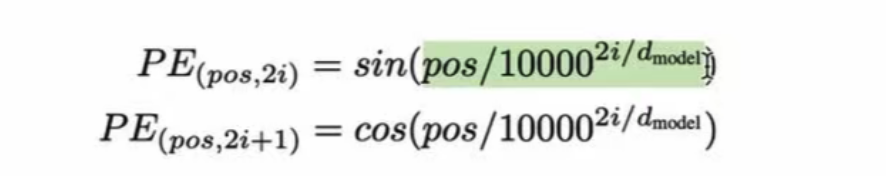

In [50]:
class PositionalEmbedding(nn.Module):
    """
    PositionalEmbedding 直接把句子长度为5000的Position Embedding 矩阵构造出来
    使用广播机制 进行构造
    先构造 i_mat矩阵 : [0, 2, 4, 6, ....] 
    再构造 pos_mat 矩阵 : [0, 1, 2 .... maxlen]
    PE矩阵 偶数列2i, 用sin函数, sin(pos_mat[2i]/1000^(i_mat[i]/dim_model))
    PE矩阵 奇数列2i+1, 用cos函数, sin(pos_mat[2i+1]/1000^(i_mat[i]/dim_model))
    """
    def __init__(self, dim_model, dropout, max_len = 5000):
        super(PositionalEmbedding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # 用广播开始计算PE矩阵
        self.pe = torch.zeros(max_len, dim_model)
        pos_mat = torch.arange(0, max_len).unsqueeze(1)
        i_mat = torch.arange(0, dim_model, 2).unsqueeze(0)
        # 用pos_mat 和 i_mat 开始广播构造PE
        self.pe[:, 0::2] = torch.sin(pos_mat / torch.pow(10000, i_mat/dim_model))
        self.pe[:, 1::2] = torch.cos(pos_mat / torch.pow(10000, i_mat/dim_model))

        # 此时pe.shape = (numsteps, dim_model) 需要再添加batch维度, 方便等会给神经网络的数据添加位置编码
        self.pe = self.pe.unsqueeze(0)

    def forward(self, x) :  

        # 这里PE矩阵不变, 因此false
        x = x + nn.Parameter(self.pe[:, :x.shape[1], :], requires_grad=False)
        return self.dropout(x)
    

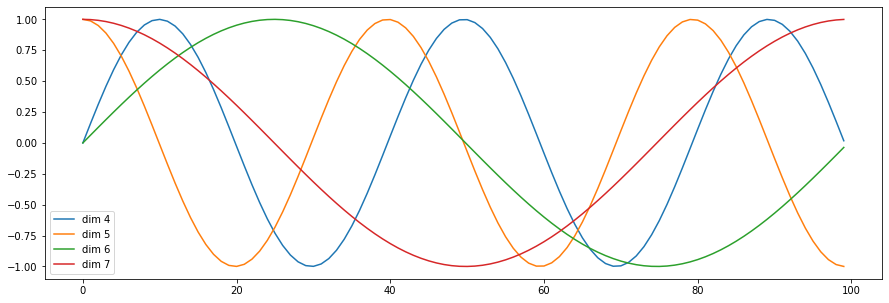

In [51]:
plt.figure(figsize=(15, 5))
position_embedding = PositionalEmbedding(20, 0)
y = position_embedding.forward(torch.zeros(1, 100, 20))
plt.plot(np.arange(100), y[0, :, 4:8].data.numpy())
plt.legend(["dim %d"%p for p in [4,5,6,7]])

## EncoderDecoder 类 (把上述组合在一起)

先根据Transformer的图构建出一个整体的流程

总共三个模块 : encoder(含有embedding层), decoder(含有embedding层), generator 

In [52]:
class EncoderDecoder(nn.Module):
    """
    EncoderDecoder 是串起整个模块流程的大类, 他的任务就是把各个模块进行组装
    """
    def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):
        super(EncoderDecoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.generator = generator
        
    def forward(self, src, tgt, src_mask, tgt_mask):
        return self.decode(self.encode(src, src_mask), src_mask, tgt, tgt_mask)
    
    def encode(self, src, src_mask):
        return self.encoder(self.src_embed(src), src_mask)
    
    def decode(self, memory, src_mask, tgt, tgt_mask):
        return self.decoder(self.tgt_embed(tgt), memory, src_mask, tgt_mask)

## 完整的模型

这里用EncoderDecoder类把上面的所有模块串在一起形成一个完整的模型

In [53]:
def make_model(src_vocab, tgt_vocab, num_layers=6, dim_model=512, 
               dim_ff = 2048, num_heads = 8, dropout = 0.1):


    # 实现三个主要模块方便后面使用
    multi_atten = MultiHeadedAttention(num_heads, dim_model)
    ffn = PositionwiseFeedForward(dim_model, dim_ff=dim_ff)
    position_embedding = PositionalEmbedding(dim_model, dropout)

    # 模型的Encoder
    encoder_layer = EncoderLayer(model_dim=dim_model, 
                                 self_atten=copy.deepcopy(multi_atten),
                                 feed_forward=copy.deepcopy(ffn),
                                 dropout=dropout)
    encoder = Encoder(layer=encoder_layer, num_layers=num_layers)

    # 模型的Decoder
    decoder_layer = DecoderLayer(model_dim=dim_model,
                                 self_atten=copy.deepcopy(multi_atten),
                                 src_atten=copy.deepcopy(multi_atten),
                                 feed_forward=ffn,
                                 dropout=dropout)
    decoder = Decoder(layer=decoder_layer, num_layers=num_layers)

    # 模型的Generator层
    generator = Generator(dim_model=dim_model,
                          vocab=tgt_vocab)
    
    # src和tgt数据的位置编码
    src_embeedings = nn.Sequential(TokenEmbedding(dim_model=dim_model,
                                              vobal=src_vocab),
                                    copy.deepcopy(position_embedding))
    
    tgt_embeddings = nn.Sequential(TokenEmbedding(dim_model=dim_model,
                                              vobal=tgt_vocab),
                                    copy.deepcopy(position_embedding))

    # 全部组装在EncoderDecoder大类中
    model = EncoderDecoder(encoder=encoder,
                           decoder=decoder,
                           src_embed=src_embeedings,
                           tgt_embed=tgt_embeddings,
                           generator=generator)
    
    for p in model.parameters():
        if p.dim() > 1 :
            nn.init.xavier_uniform_(p)
    
    return model

In [54]:
# Small example model.
model = make_model(10, 10, 2)
None

以上是Transformer完整的模型

# Training 训练

## 训练时候的batch类

定义训练的batch, 保存训练的Src 和 target 句子, 已经训练用的Mask

In [ ]:
class Batch:
    "存储训练用的数据和mask"
    def __init__(self, src, trg=None, pad=0):
        # src 的 shape是[batchsize, seq_len]
        # src_mask 的 shape 是 [batchsize, query_len = 1, key_len], src_mask中True代表padding，False代表真实值
        
        self.src = src
        self.src_mask = (src != pad).unsqueeze(-2) # 这里pad是0, 因此src_mask中True代表padding，False代表真实值
        if trg is not None:
            # 训练时候用到的翻译的结果
            # trg是输入上一个词语的结果
            # trg_y是神经网络预测出下一个词语的目标样本
            self.trg = trg[:, :-1]
            self.trg_y = trg[:, 1:]
            self.trg_mask = self.make_std_mask(self.trg, pad)
            self.num_tokens = (self.trg_y != pad).data.sum()

    def make_std_mask(self, tgt, pad):
        "tgt_mask已经mask了无用的信息, 再结合subsequent_mask, 是decoder中masked self attention使用的mask"
        # tgt_mask 为True代表要遮蔽, False代表有效的值, 从[batchsize, key_len]变为[batchsize, query_len = 1, key_len]
        tgt_mask = (tgt != pad).unsqueeze(-2)
        tgt_mask = tgt_mask &  subsequent_mask(tgt_mask.shape[-1]).to(dtype=tgt_mask.dtype)
        return tgt_mask

## Training Loop 训练循环 (训练过程看这里)

In [56]:
def run_epoch(data_iter, model, loss_compute):
    """
    把src和trg[:, :-1] 丢入到Transformer当中, 得到out.shape = (batchsize, numsteps -1, dim_model)
    然后丢入到Loss当中, 在loss_compute当中会用generator 把out.shape变为 (batchsize, numsteps -1, vobal_size)
    然后和trg[:, 1:] 的预测目标进行对比, 计算loss, 然后更新梯度
    

    Args:
        data_iter (_type_): batch包装好的训练数据集
        model (_type_): 模型
        loss_compute (_type_): 自定义Loss, 内有model.generator, 会把输入(batchsize, numsteps -1, dim_model) 
                                转变为(batchsize, numsteps -1, vobal_size), 并且用了平滑标签损失函数计算loss, 然后用loss_compute.optimizer.step()会先更新学习率, 
                                然后loss_compute.opt.optimizer.zero_grad() 清空梯度



    Returns:
        _type_: 返回这个batch的平均loss
    """
    # total_tokens 是 所有batch 所有样本加一起的有效token
    # total_loss 同理
    start = time.time()
    total_tokens = 0
    total_loss = 0
    tokens = 0
    for i, batch in enumerate(data_iter):
        out = model.forward(batch.src, batch.trg, batch.src_mask, batch.trg_mask)
        # 在这里计算loss, 更新梯度, 然后清空梯度
        loss = loss_compute(out, batch.trg_y, batch.num_tokens)
        total_loss += loss
        total_tokens += batch.num_tokens
        tokens += batch.num_tokens
        
        # 如果是训练模式下, 就每训练50轮打印下训练情况
        if model.training and i % 50 == 1 :
            elapsed = time.time() - start
            print("Epoch Step : %d Loss : %f Tokens Sec:%f" 
                  %(i, loss/batch.num_tokens, tokens/elapsed))
            start = time.time()
            tokens = 0
    return total_loss / total_tokens

## Noamopt 学习率调节

Noamopt是Transformer提出来的学习率调节策略

核心思想 : 训练初期先线性升高学习率，然后按步数的倒数平方根衰减

目的 : 前期让神经网络快速收敛, 后期减小学习率, 让模型更加稳定

Noamopt学习率调节公式

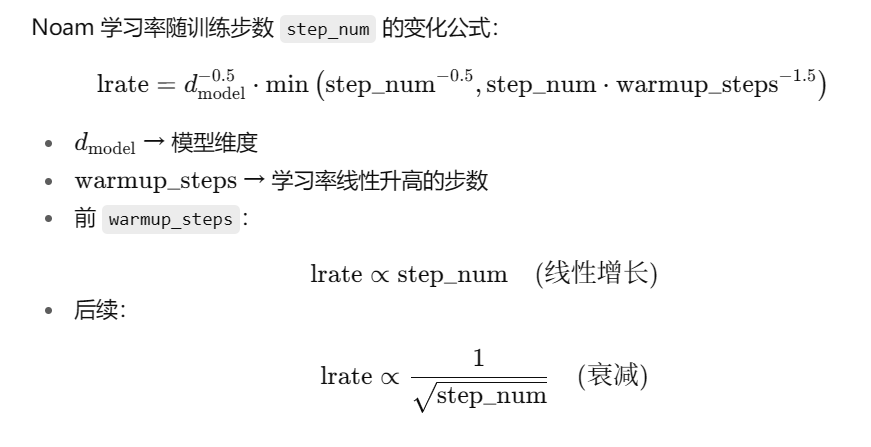

In [57]:
class NoamOpt:
    """
    Optim wrapper that implements rate.
    dim_model 是模型的特征维度长度
    _step记录当前是第几个step
    warmup是增长学习率的轮数
    """
    def __init__(self, dim_model, factor, warmup, optimizer):
        self.optimizer = optimizer
        self._step = 0
        self.warmup = warmup
        self.factor = factor
        self.dim_model = dim_model
        self._rate = 0
    
    def step(self):
        "先调整下学习率, 然后再用Adam调整学习率"
        self._step += 1
        rate = self.compute_rate()
        for p in self.optimizer.param_groups:
            p['lr'] = rate
        self._rate = rate
        self.optimizer.step()
        
    def compute_rate(self, step = None):
        "计算当前的学习率"
        if step is None : 
            step = self._step
        return self.factor * \
            (self.dim_model ** (-0.5) *
            min(step ** (-0.5), step * self.warmup ** (-1.5)))

创建一个get_std_opt函数, 功能就是把参数放入到Adam优化器当中, 然后再把Adam优化器放入到Noamopt当中 , 然后返还Noamopt优化器

In [58]:
def get_std_opt(model):
    "获取一个NoamOpt"
    
    # 这里model.src_embed = [Token embedding, Position embedding]
    # 这里取Token embedding 然后 找到里面的dim_model
    return NoamOpt(dim_model = model.src_embed[0].dim_model,
                   factor = 2,
                   warmup = 4000,
                   optimizer = torch.optim.Adam(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9))

画图看看不同参数下的NoamOpt的学习率情况


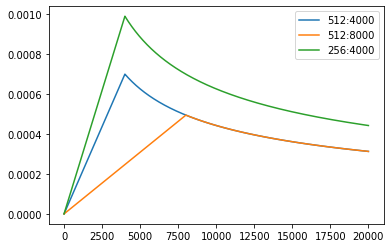

In [59]:
opts = [NoamOpt(512, 1, 4000, None),
        NoamOpt(512, 1, 8000, None),
        NoamOpt(256, 1, 4000, None)]

plt.plot(np.arange(1, 20000), [[opt.compute_rate(i) for opt in opts] for i in range(1, 20000)])
plt.legend(["512:4000", "512:8000", "256:4000"])
None

## 正则化 -- 标签平滑
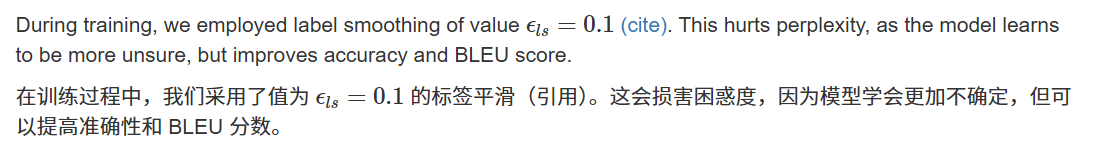

[标签平滑](https://arxiv.org/abs/1512.00567)

标签平滑技术 : 
分类问题(举例用N分类问题)当中, 本来网络对于正确分类的目标是1, 对于错误分类的目标是0

但是这会导致神经网络过于自信, 同时如果样本当中出现错误, 那么会让网络的一个训练的效果不好, 抗干扰的能力不行

因此引入ε变量, 让正确分类的目标是1-ε+ε/N, 错误分类的目标是ε/N, 这样的概率合也是1

一般用的是one-hot编码, 原本[1, 0, 0]的目标结果就变成了[1-ε+ε/N, ε/N, ε/N]

这里似乎是排除了正确类, 则原本[1, 0, 0]的目标结果就变成了[1-ε, ε/(N-1), ε/(N-1)]

### KL散度

softmax里面会用到KL散度来衡量两个向量的距离

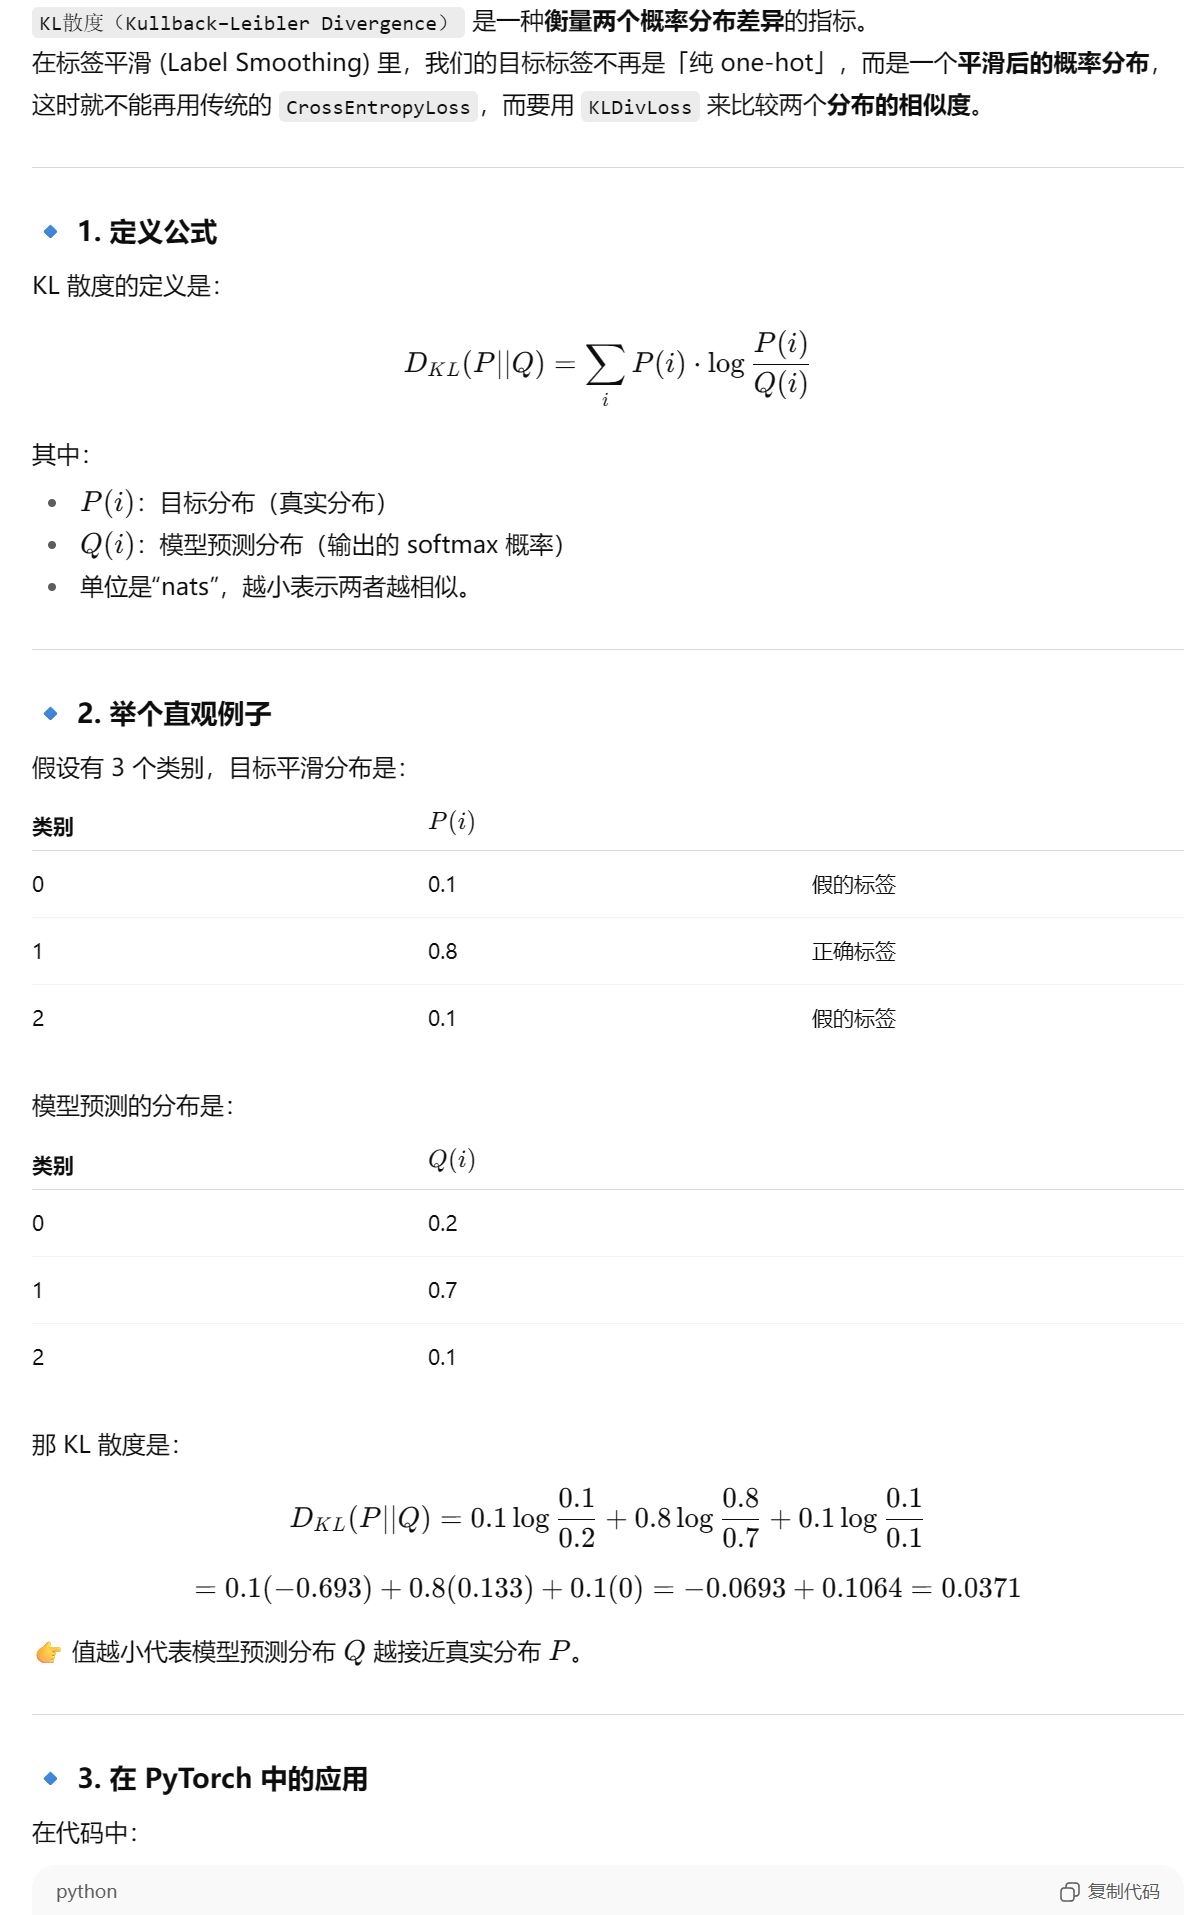

### Transformer标签平滑实现

In [60]:
class LabelSmoothing(nn.Module):
    """
    输入 : x.shape = [batchsize * (num_steps-1), vobal_size] 进入之前会拉平, 因为nn.KLDivLoss 的输入要求是 二维的！
    
    
    forward输入 : 
    1. x预测结果 [batchsize * (num_steps-1), vobal_size]
    2. target目标结果 [batchsize * (num_steps-1)]
    因为他是样本, 预测的输入是前numsteps-1, 然后分别预测后面一个位置的数据, 因此是target样本是 [batchsize*(num_steps-1)]
    """
    def __init__(self, vobal_size, padding_idx, smoothing = 0.0):
        super(LabelSmoothing, self).__init__()
        # 衡量两个向量的距离KL散度, 求和方式
        self.criterion = nn.KLDivLoss(reduction='sum')
        # padding_idx是个数字, 代表预测出来的第几类其实是padding
        self.padding_idx = padding_idx
        # 公式里面1-ε
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        # 要分类的总数
        self.vobal_size = vobal_size
        
        # 用来保存 每个样本的平滑后的目标分布, 注意是目标分布
        self.true_dist = None
        
    def forward(self, x, target):
        # x的是形状是[batchsize * (num_steps-1), vobal_size]
        assert x.shape[1] == self.vobal_size
        true_dist = x.data.clone()
        
        # 这里先给true_dist里面的数据填充 错误类别的目标概率 [ε/N] 
        # 这里2是排除了正确类和padding类
        true_dist.fill_(self.smoothing / (self.vobal_size - 2))
        
        # scatter_(dim, index, src)
            # dim=1：沿列操作（每行选择正确类别）
            # index：每行要修改的列索引
            # src：要填的值
        # 使用scatter_函数给true_dist正确类的位置填充confidence值 1-ε
        # target 是正确类的形状   [batchsize * (num_steps-1), 1]
        true_dist.scatter_(dim=1, index = target.unsqueeze(1).long(), value = self.confidence)
        
        # 这里把padding的地方, 设置true_dist 的分类后的预测目标是0
        # true_dist 为(batchsize * max_seq_len, vobal_size)
        true_dist[:, self.padding_idx] = 0
        
        # 有些token其实也是padding 出来的, 因为不同句子不同长度, 因此目标那一整行都要是0
        # target中数值是padding_idx代表那个token是padding出来的
        mask = torch.nonzero(target.data == self.padding_idx)
        if mask.dim() > 0:
            # 0代表对行进行处理, mask.squeeze代表是行索引, 这些行全部置为0
            true_dist.index_fill(0, mask.squeeze(), 0.0)
            
        self.true_dist = true_dist
        
        return self.criterion(x, true_dist.detach())

写一个会打印信息的标签平滑的类, 感觉这里逻辑有点搞不清楚

In [61]:
class LabelSmoothingPrint(nn.Module):
    """
    Label Smoothing 示例 + 每一步打印每行数据
    
    true_list.shape 为 (batchsize * numsteps-1, vobal_size) 代表 每个token对于这个token是哪个token的分类预测
    
    """
    def __init__(self, vocab_size, padding_idx, smoothing=0.0):
        super(LabelSmoothingPrint, self).__init__()
        self.criterion = nn.KLDivLoss(reduction='sum')
        self.padding_idx = padding_idx
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.vocab_size = vocab_size
        self.true_dist = None

    def forward(self, x, target):
        assert x.shape[1] == self.vocab_size
        true_dist = x.data.clone()
        print("步骤0：克隆 x.data")
        print(true_dist)

        true_dist.fill_(self.smoothing / (self.vocab_size - 2))
        print("\n步骤1：填充平滑概率 ε / (vocab_size-2)")
        print(true_dist)

        true_dist.scatter_(dim=1, index=target.unsqueeze(1), src=torch.full_like(target.unsqueeze(1), self.confidence, dtype=torch.float))
        print("\n步骤2：给正确类别填充置信度 1-ε")
        print(true_dist)

        true_dist[:, self.padding_idx] = 0
        print("\n步骤3：将 padding 列置 0")
        print(true_dist)

        # ===== 新增打印 mask =====
        mask = torch.nonzero(target.data == self.padding_idx)
        print("\n步骤4a：padding 行索引 mask = torch.nonzero(target.data == padding_idx)")
        print(mask)

        if mask.dim() > 0:
            true_dist.index_fill_(0, mask.squeeze(), 0.0)
            print("\n步骤4b：将 padding 行置 0")
            print(true_dist)

        self.true_dist = true_dist
        return self.criterion(x, true_dist.detach())

### 运行LabelSmoothing类


步骤0：克隆 x.data
tensor([[   -inf, -1.6094, -0.3567, -2.9957, -2.9957],
        [   -inf, -1.6094, -0.3567, -2.9957, -2.9957],
        [   -inf, -1.6094, -0.3567, -2.9957, -2.9957]])

步骤1：填充平滑概率 ε / (vocab_size-2)
tensor([[0.1333, 0.1333, 0.1333, 0.1333, 0.1333],
        [0.1333, 0.1333, 0.1333, 0.1333, 0.1333],
        [0.1333, 0.1333, 0.1333, 0.1333, 0.1333]])

步骤2：给正确类别填充置信度 1-ε
tensor([[0.1333, 0.1333, 0.6000, 0.1333, 0.1333],
        [0.1333, 0.6000, 0.1333, 0.1333, 0.1333],
        [0.6000, 0.1333, 0.1333, 0.1333, 0.1333]])

步骤3：将 padding 列置 0
tensor([[0.0000, 0.1333, 0.6000, 0.1333, 0.1333],
        [0.0000, 0.6000, 0.1333, 0.1333, 0.1333],
        [0.0000, 0.1333, 0.1333, 0.1333, 0.1333]])

步骤4a：padding 行索引 mask = torch.nonzero(target.data == padding_idx)
tensor([[2]])

步骤4b：将 padding 行置 0
tensor([[0.0000, 0.1333, 0.6000, 0.1333, 0.1333],
        [0.0000, 0.6000, 0.1333, 0.1333, 0.1333],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])


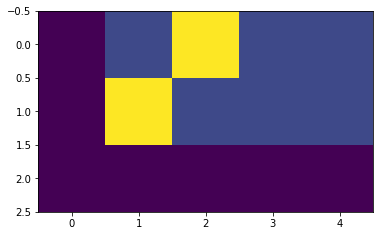

In [62]:
crit = LabelSmoothingPrint(vocab_size=5, padding_idx=0, smoothing=0.4)
predict = torch.FloatTensor([[0, 0.2, 0.7, 0.05, 0.05],
                             [0, 0.2, 0.7, 0.05, 0.05], 
                             [0, 0.2, 0.7, 0.05, 0.05]])
v = crit(x = predict.log().detach(), 
         target = torch.LongTensor([2, 1, 0]).detach())

plt.imshow(crit.true_dist)
None

如果模型对某个选择非常自信, 那么标签平滑损失函数就会惩罚模型 (即算出来的损失函数会增大)

下方模拟 : 
最终的目标是[0.9, 0.03, 0.03, 0.03], 当对预测值过于自信的时候, 就会让他算出来的Loss增大

目标序列大小:  tensor([[0.0000, 0.9000, 0.0333, 0.0333, 0.0333]])

预测序列大小  tensor([[0.0000, 0.9032, 0.0323, 0.0323, 0.0323]])

上一次预测序列大小  tensor([[0.0000, 0.9000, 0.0333, 0.0333, 0.0333]])

x  28  last loss  0.0  loss  5.893898196518421e-05


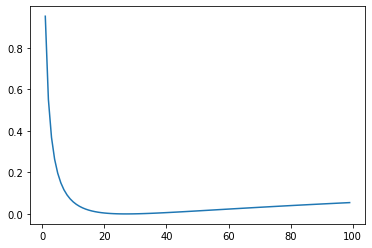

In [63]:
crit = LabelSmoothing(vobal_size = 5, padding_idx=0, smoothing=0.1)
last_loss = 100
last_predict = []
flag = 0

def loss(x):
    global flag, last_loss, last_predict
    d = x + 3*1
    predict = torch.tensor([
                            [0, x/d, 1/d, 1/d, 1/d]
                            ])
    loss = crit(predict.log().detach(), torch.LongTensor([1]).detach()).item()
    if last_loss < loss and flag == 0 :
        # 只打印拐角
        flag = 1
        print("目标序列大小: ", crit.true_dist)
        print("\n预测序列大小 ", predict)
        print("\n上一次预测序列大小 ", last_predict)
        print("\nx ", x, " last loss ", last_loss," loss ", loss )
        
    last_loss = loss
    last_predict = predict
    return loss

plt.plot(np.arange(1, 100), [loss(x) for x in range(1, 100)])
None

# 跑第一个例子

我们可以从一个简单的复制任务开始尝试。给定来自小词汇表的一组随机输入符号，目标是生成相同的符号。

## Synthetic Data  合成数据

In [64]:
def data_gen(vobal_size, size_batch, num_batch):
    """
    生成(batch_size, numsteps = 10) 丢入到Batch中

    Variable : 
    vobal_size 是词表的大小
    size_batch 是一个batch里面有几个样本
    num_batch 是总共生成几组batch
    
    Returns: 返回包装好的Batch数据集
    """
    # num_batch是总共要生成几个batch
    # size_batch是一个batch里面有几个句子
    for i in range(num_batch):
        data = torch.tensor(np.random.randint(1, vobal_size, size=(size_batch, 10)))
        # 在NLP里面start token 为1, padding 为 0
        data[:, 0] = 1
        src = data.detach()
        tgt = data.detach()
        yield Batch(src = src, trg = tgt, pad = 0)

## SimpleLossCompute class 损失类计算

这个类从跑完Transformer后的x丢到softmax分类器(generator), 然后应用标签平滑版本的Loss

In [65]:
class SimpleLossCompute : 
    """
    标签平滑的损失函数 + Namopt 组合在一起
    """
    def __init__(self, generator, criterion, opt=None):
        self.generator = generator
        self.criterion = criterion
        self.opt = opt
    
    def __call__(self, x, y, norm):
        # 根据trainingLoop的描述, 这里norm是这个batch里面有效的tokens的数量
        # 因为Transformer的loss是token来计算的(注意每个句子的有效token不一样)
        x = self.generator(x)
        
        # 这里把x 从[batchsize, numsteps, vobalsize] 变成 [batchsize * numsteps, vobal_size]
        # y 从[batchsize, numsteps] 变成 [batchsize * numsteps]
        loss = self.criterion(x.contiguous().view(-1, x.shape[-1]),
                              y.contiguous().view(-1)) / norm
        loss.backward()
        
        if self.opt is not None:
            self.opt.step()
            self.opt.optimizer.zero_grad()
        return loss.item() * norm

## 开始训练

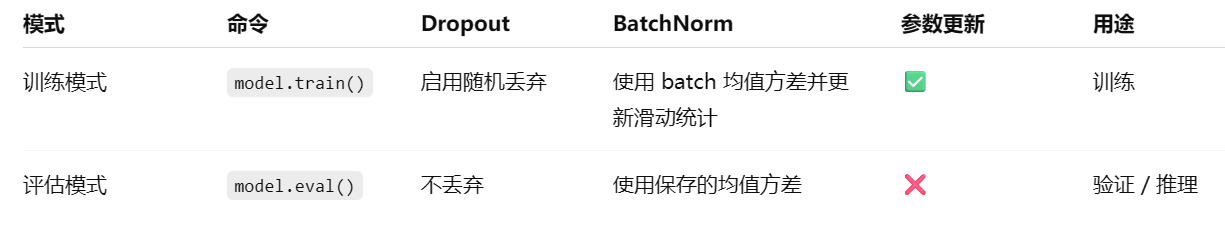

In [66]:
vobal_size = 11
criterion = LabelSmoothing(vobal_size=vobal_size, padding_idx=0, smoothing=0.0)
model = make_model(src_vocab=vobal_size, tgt_vocab=vobal_size, num_layers=1)
model_opt = NoamOpt(model.src_embed[0].dim_model, 1, 400,
        torch.optim.Adam(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9))

for epoch in range(10):
    model.train()
    # 训练一个epoch
    run_epoch(data_gen(vobal_size, 30, 20), model, 
              SimpleLossCompute(model.generator, criterion, model_opt))
    model.eval()
    # 打印下
    print(run_epoch(data_gen(vobal_size, 30, 5), model, 
                    SimpleLossCompute(model.generator, criterion, None)))




Epoch Step : 1 Loss : 3.058091 Tokens Sec:1125.564087
tensor(2.0493)
Epoch Step : 1 Loss : 2.179602 Tokens Sec:1266.093140
tensor(1.6711)
Epoch Step : 1 Loss : 1.777073 Tokens Sec:1234.564209
tensor(1.1738)
Epoch Step : 1 Loss : 1.343176 Tokens Sec:1206.128784
tensor(0.9649)
Epoch Step : 1 Loss : 1.160192 Tokens Sec:1091.147949
tensor(0.6477)
Epoch Step : 1 Loss : 0.788079 Tokens Sec:1150.964966
tensor(0.3774)
Epoch Step : 1 Loss : 0.450016 Tokens Sec:1228.197021
tensor(0.2995)
Epoch Step : 1 Loss : 0.588699 Tokens Sec:1158.738159
tensor(0.2341)
Epoch Step : 1 Loss : 0.303401 Tokens Sec:1235.979736
tensor(0.1462)
Epoch Step : 1 Loss : 0.525790 Tokens Sec:1213.695312
tensor(0.2135)


## 预测

预测是一个个预测的, 先告知他第一个字符, 然后预测第二个, 然后把再根据这两个字符预测第三个 

In [ ]:
model.eval()
# src的维度是[batchsize, numsteps]
src = torch.tensor(np.arange(1, 11)).unsqueeze(0)

# mask的维度是[batchsize, query_len, key_len], query_len维度一般可以直接是1, 因为mask其实是对key进行屏蔽, 每个query对同一个key都是一个情况, 所以可以广播
src_mask = torch.ones(1, 1, 10)
# 假设最后一个token是填充的, True代表真实值, False代表padding值
src_mask[:, :, -1] = 0

memory = model.encode(src, src_mask)

# 已知道src第一个字符是什么, 开始预测
tgt = torch.ones(1,1).fill_(1).to(dtype=src.dtype)
for i in range(src.shape[1]-1) : 
    out = model.decode(memory=memory, src_mask=src_mask, 
                       tgt=tgt, 
                       tgt_mask=subsequent_mask(tgt.shape[1]).to(dtype=src_mask.dtype))
    # out.shape = [batchsize, tgt_len, dim_model]
    # prob.shape = [batchsize, dim_mdoel] 使用切片会把被索引维度去掉
    prob = model.generator(out[:, -1, :])
    values, indices = torch.max(prob, dim=1)
    next_word = indices.item()
    tgt = torch.cat([tgt, torch.ones(1, 1).fill_(next_word).to(dtype = tgt.dtype)],
                    dim=1)
print(tgt)


tensor([[1, 2, 3, 4, 5, 6, 7, 8, 9, 9]], dtype=torch.int32)


# 看下神经网络的结构

In [68]:
# 定义一个 forward hook
def print_forward_hook(module, input, output):
    print(f"Forward through {module._get_name()} | input shape: {[i.shape for i in input]} | output shape: {output.shape if isinstance(output, torch.Tensor) else 'non-tensor'}")

# 遍历模型所有子模块，注册 hook
hooks = []
for name, module in model.named_modules():
    # 避免重复打印顶层模型（EncoderDecoder）本身，可以只选 nn.Module 子类
    if len(list(module.children())) == 0:
        hooks.append(module.register_forward_hook(print_forward_hook))

# 构造一个 dummy batch
src = torch.randint(1, vobal_size, (2, 10))
tgt = torch.randint(1, vobal_size, (2, 10))
src_mask = torch.ones(2, 1, 10)
tgt_mask = torch.ones(2, 10, 10)

# 执行一次 forward，触发 hook
model(src, tgt, src_mask, tgt_mask)

# 用完后可以移除 hook
for h in hooks:
    h.remove()


Forward through Embedding | input shape: [torch.Size([2, 10])] | output shape: torch.Size([2, 10, 512])
Forward through Dropout | input shape: [torch.Size([2, 10, 512])] | output shape: torch.Size([2, 10, 512])
Forward through LayerNorm | input shape: [torch.Size([2, 10, 512])] | output shape: torch.Size([2, 10, 512])
Forward through Linear | input shape: [torch.Size([2, 10, 512])] | output shape: torch.Size([2, 10, 512])
Forward through Linear | input shape: [torch.Size([2, 10, 512])] | output shape: torch.Size([2, 10, 512])
Forward through Linear | input shape: [torch.Size([2, 10, 512])] | output shape: torch.Size([2, 10, 512])
Forward through Dropout | input shape: [torch.Size([2, 8, 10, 10])] | output shape: torch.Size([2, 8, 10, 10])
Forward through Linear | input shape: [torch.Size([2, 10, 512])] | output shape: torch.Size([2, 10, 512])
Forward through Dropout | input shape: [torch.Size([2, 10, 512])] | output shape: torch.Size([2, 10, 512])
Forward through LayerNorm | input shap

后面还有在多GPU上跑真实样本的例子, 这里就不复现了,不确定用不用的上